# **Predict Ames Homes Prices ---- Advanced Regression Technique**

# **06. Data Cleaning & Experiment Notebook**

# __Introduction__
The Ames Housing dataset provides detailed information on properties sold in Ames, Iowa, from 2006 to 2010. With its diverse range of features and real-world complexities, it serves as an excellent dataset for demonstrating __data cleaning, preprocessing techniques and do some experiments__ for futhur analysis.


## __Business Objective__

In today's dynamic real estate market, accurate house price prediction is crucial for various stakeholders:
 - **Home Buyers** : Want to ensure making fair offers.
 - **Sellers** : Need to set compeitive listing prices.
 - **Real Estate Agents** : Need reliable price estimates to advise clinets effectively.
 - **Investors** : Require accurate valuation for investment decisions.

## __Problem Statement__
This project implements a machine learning solution to analyze various house dimensions to predict sale prices, helping stakeholders to make data-driven decisions.

## __Import Libraries__

In [127]:
import os
import zipfile
import sys
sys.path.append("..")
from src.utilis import *


In [128]:
# define path
parent_path = Path.cwd().parent
data_path = parent_path.joinpath("data", "raw")
processed_path = parent_path.joinpath("data", "processed")

org_files = []
display_md("**Original Files :**")
for file in data_path.rglob("*.csv"):
    org_files.append(file)
    print(org_files.index(file), " ", file.name)

pro_files = []
display_md("**Cleaned Files :**")
for fle in processed_path.rglob("*"):
    pro_files.append(fle)
    print(pro_files.index(fle), " ", fle.name)


**Original Files :**

0   sample_submission.csv
1   test.csv
2   train.csv


**Cleaned Files :**

0   .gitkeep
1   test_cleaned.csv
2   train_cleaned.csv


In [129]:
display_md("**Loading Original Datasets :**")

# Load original data 
train_org = load_data(org_files[2])
test_org = load_data(org_files[1])    

# standardize the column names
train_org.columns = train_org.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")
test_org.columns = test_org.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")

display_md("**Original Training and Testing data Shape**")

print("Original Training data shape: ", train_org.shape)
print("Original Testing data shape: ", test_org.shape)

display_md("**Duplicate Rows in  Data**")

print("Number of duplicate rows in training data: ", train_org.duplicated().sum())
print("Number of duplicate rows in testing data ", test_org.duplicated().sum())

df_train = train_org.copy()
df_test = test_org.copy()



**Loading Original Datasets :**

Data loaded successfully!
Data loaded successfully!


**Original Training and Testing data Shape**

Original Training data shape:  (1460, 81)
Original Testing data shape:  (1459, 80)


**Duplicate Rows in  Data**

Number of duplicate rows in training data:  0
Number of duplicate rows in testing data  0


In [130]:
# Set `Id` as index of datasets
df_train = df_train.set_index(['Id'])
df_test = df_test.set_index(['Id'])

# Save test IDs for later use
test_ids = df_test.index

# Seperate features and target variable
X_train = df_train.drop(['SalePrice'], axis=1)
y = df_train['SalePrice']

# Concatenate train and test data
X = pd.concat([X_train, df_test], axis=0)




In [131]:
# Segregate numerical and categorical features
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
print(f"Total Numerical Columns : {len(num_cols)}", num_cols)

Total Numerical Columns : 36 ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


In [132]:
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()
print(f"Total Categorical Columns : {len(cat_cols)}\n", cat_cols)


Total Categorical Columns : 43
 ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [133]:
dtype_df = datatype_df(df_train)
display(dtype_df.head())


,Dtype,nunique,unique,missing_value
MSSubClass,int64,15,"[60, 20, 70, 50, 190, 45, 90, 120, 30, 85, 80,...",0
MSZoning,object,5,"[RL, RM, C (all), FV, RH]",0
LotFrontage,float64,110,"[65.0, 80.0, 68.0, 60.0, 84.0, 85.0, 75.0, nan...",259
LotArea,int64,1073,"[8450, 9600, 11250, 9550, 14260, 14115, 10084,...",0
Street,object,2,"[Pave, Grvl]",0


In [134]:
# Store features in different groups based on their data type

ordinal_num_var = ['OverallQual', 'OverallCond', 'BsmtFullBath','BsmtHalfBath',
                   'FullBath','HalfBath','BedroomAbvGr','KitchenAbvGr','TotRmsAbvGrd','Fireplaces','GarageCars']

convert_cat_var = ['MSSubClass', 'YrSold', 'MoSold']

numeric_var = [col for col in df_train.select_dtypes(include=np.number).columns 
               if col not in ordinal_num_var + convert_cat_var and col != 'SalePrice']

# ordinal categorical features based on quality and condition
ordinal_qual_cond_var = ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC',
                         'KitchenQual','FireplaceQu','GarageQual','GarageCond','PoolQC']

# ordinal categorical features based on basement and finish types
ordinal_bsmt_fin_var = ['BsmtFinType1', 'BsmtFinType2', 'BsmtExposure', 'GarageFinish']

# ordinal features based on functional and utility 
ordinal_fun_util_var = ['LotShape', 'Fence', 'Functional', 'Utilities']

# nominal categorical features
cat_var = [col for col in df_train.select_dtypes(include=['object']).columns 
           if col not in ordinal_qual_cond_var + ordinal_bsmt_fin_var + ordinal_fun_util_var]


## **2. Exploratory Data Analysis**

#### **2.1. Sale Price**

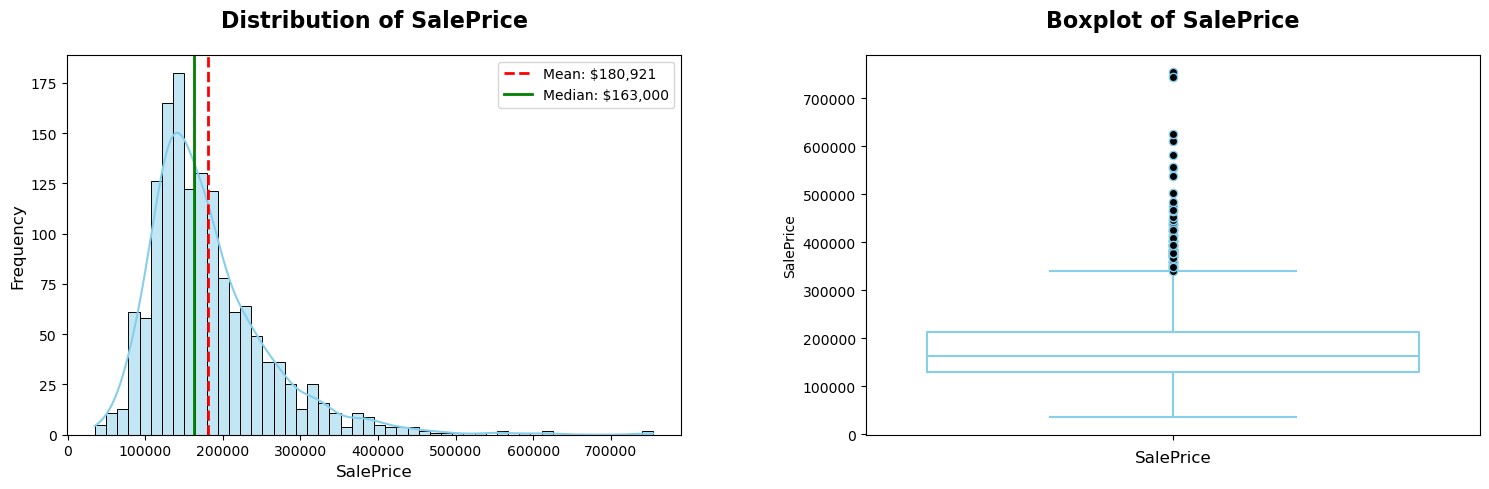

In [135]:
# Calculate statistics
mean_price = y.mean()
median_price = y.median()

# Plot histogram with KDE
fig, ax = plt.subplots(1, 2, figsize=(15,5))
sns.histplot(y, kde=True, bins=50, color='skyblue', ax=ax[0])

# Add mean and median lines
ax[0].axvline(mean_price, color="red", linestyle="--", linewidth=2, label=f"Mean: ${mean_price:,.0f}")
ax[0].axvline(median_price, color="green", linestyle="-", linewidth=2, label=f"Median: ${median_price:,.0f}")

# Labels and legend
ax[0].set_title("Distribution of SalePrice", fontsize=16, fontweight='bold', pad=20)
ax[0].set_xlabel("SalePrice", fontsize=12)
ax[0].set_ylabel("Frequency", fontsize=12)
ax[0].legend()


# boxplot of SalePrice for outliers
sns.boxplot(y=df_train['SalePrice'], color='skyblue', fill=False, flierprops={'marker': 'o', 'markerfacecolor':'k'}, ax=ax[1])
ax[1].set_title("Boxplot of SalePrice", fontsize=16, fontweight='bold', pad=20)
ax[1].set_xlabel("SalePrice", fontsize=12)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


In [136]:
print(f"""Skewness : {y.skew():.4f}
Kurtosis : {y.kurtosis():.4f}""") # kurtosis > 3 means heavy tails, more outliers than normal


Skewness : 1.8829
Kurtosis : 6.5363


- The distribution of `SalePrice` is right-skewed. So, we can consider transformation to reduce skewness before modeling.
- Sale prices range form $34,900 to $755,000.


#### **2.2. Numerical Features**

Top 10 numerical features highly correlated with SalePrice:


In [137]:
corr_matrix = df_train.select_dtypes(include=[np.number]).corr()
top_10_corr = corr_matrix['SalePrice'].sort_values(ascending=False).head(11)
top_10_corr

SalePrice      1.00
OverallQual    0.79
GrLivArea      0.71
GarageCars     0.64
GarageArea     0.62
TotalBsmtSF    0.61
1stFlrSF       0.61
FullBath       0.56
TotRmsAbvGrd   0.53
YearBuilt      0.52
YearRemodAdd   0.51
Name: SalePrice, dtype: float64

__What are the top 10 features selected by Recursive Feature Elimination?__


In [138]:
from sklearn.feature_selection import RFE, f_regression, r_regression
from sklearn.linear_model import LinearRegression

model = LinearRegression()
rfe = RFE(estimator=model, n_features_to_select=10, step=1)
selector = rfe.fit(X_train.fillna(0).select_dtypes(exclude='object'), y)
selected_features = list(
    X_train.select_dtypes(exclude='object').columns[selector.support_]
)
display(selected_features)

display_md("Based on the analyses, features such as __Overall Quality, Living Area, Garage Size, Number of Full Baths, and Year Built__ emerge as key determinants of house prices. Let's explore these features in greater detail.")


['OverallQual',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageCars']

Based on the analyses, features such as __Overall Quality, Living Area, Garage Size, Number of Full Baths, and Year Built__ emerge as key determinants of house prices. Let's explore these features in greater detail.

**Overall Quality**

Overall quality is the most important feature in both analyses. It is clear that higher quality makes the house more expensive.



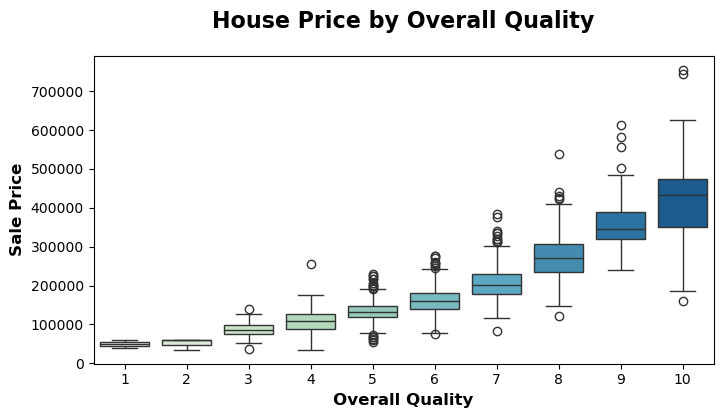

In [139]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x='OverallQual', y='SalePrice', data=df_train, palette='GnBu')
ax.set_title('House Price by Overall Quality', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Overall Quality', fontsize=12, fontweight='bold')
ax.set_ylabel('Sale Price', fontsize=12, fontweight='bold')
plt.show()


#### **Living Area**

The living area shows a clear linear relationship with house price. In the scatter plot, however, several __outliers__ are evident—most notably two properties in the lower-right corner with more than __4,000 square feet__ of living space but priced below __$200,000__.

Correlation : 0.7086244776126515


<Figure size 600x400 with 0 Axes>

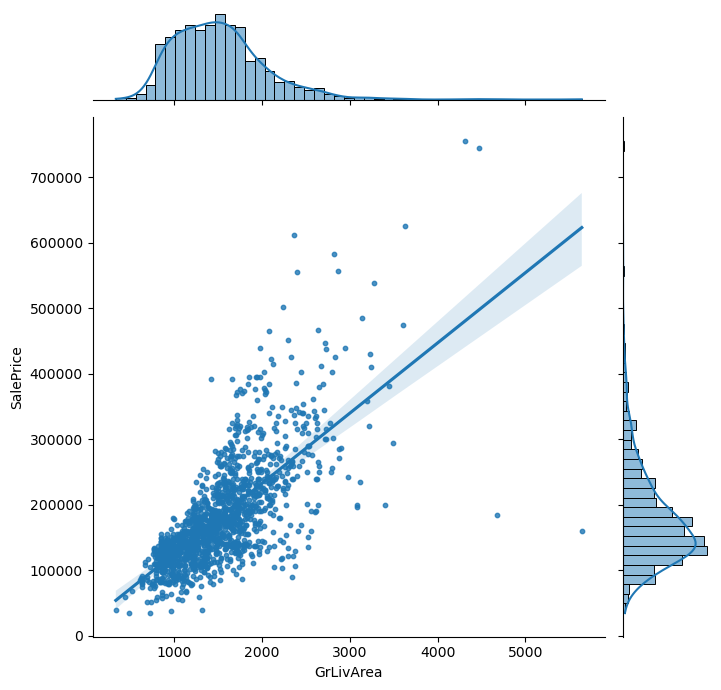

In [140]:
def plot_correlation(features):
    """
    1. Plot correlation of two features
    2. Create Joint plot of two features
    """
    # print correlation
    print("Correlation :", df_train[[features[0], features[1]]].corr().iloc[1, 0])

    # Create joint plot
    plt.figure(figsize=(6, 4))
    sns.jointplot(data = df_train, x= features[0], y=features[1], kind='reg', height=7, scatter_kws={'s': 10}, marginal_kws={'kde': True})

    plt.show()

plot_correlation(['GrLivArea', 'SalePrice']);
plt.show()


#### **GarageCars**

It's surprising that houses with __four-car garages__ are actually priced lower than those with __three-car garages__.

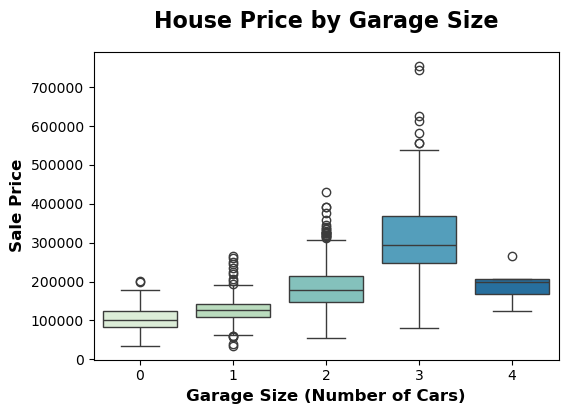

In [141]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x='GarageCars', y='SalePrice', data=df_train, palette='GnBu', ax=ax)
ax.set_title('House Price by Garage Size', fontdict={'fontsize': 16, 'fontweight': 'bold'}, y=1.05)
ax.set_xlabel('Garage Size (Number of Cars)', fontsize=12, fontweight='bold')
ax.set_ylabel('Sale Price', fontsize=12, fontweight='bold')
plt.show()


#### **Year Built**

The age of a house is another key factor influencing its price. In general, newer homes command higher average values, though there are also several pre‑1900 properties that stand out with notably high prices.

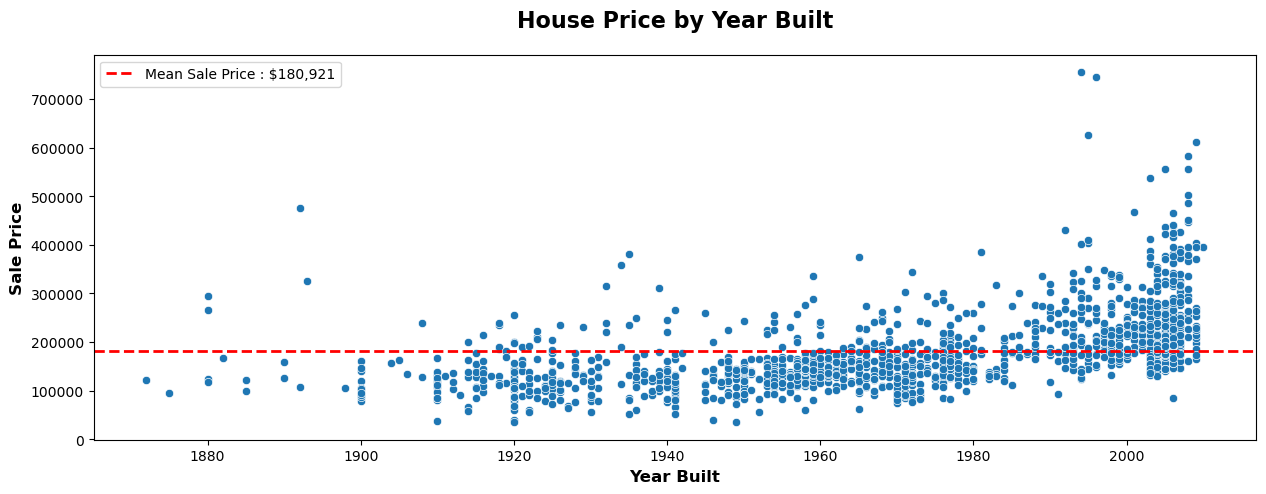

In [142]:
fig, ax = plt.subplots(figsize=(15, 5))
overall_mean = df_train['SalePrice'].mean()
sns.scatterplot(x='YearBuilt', y='SalePrice', data=df_train, ax=ax)
ax.axhline(overall_mean, color='r', ls='--', lw=2, label=f'Mean Sale Price : ${overall_mean:,.0f}')

ax.set_title('House Price by Year Built', fontdict={'fontsize': 16, 'fontweight': 'bold'}, y=1.05)
ax.set_xlabel('Year Built', fontsize=12, fontweight='bold')
ax.set_ylabel('Sale Price', fontsize=12, fontweight='bold')
ax.legend()

plt.show()


#### **2.3. Bivariate Plots ---- Impact of Log and Square Transformations on Linearity**

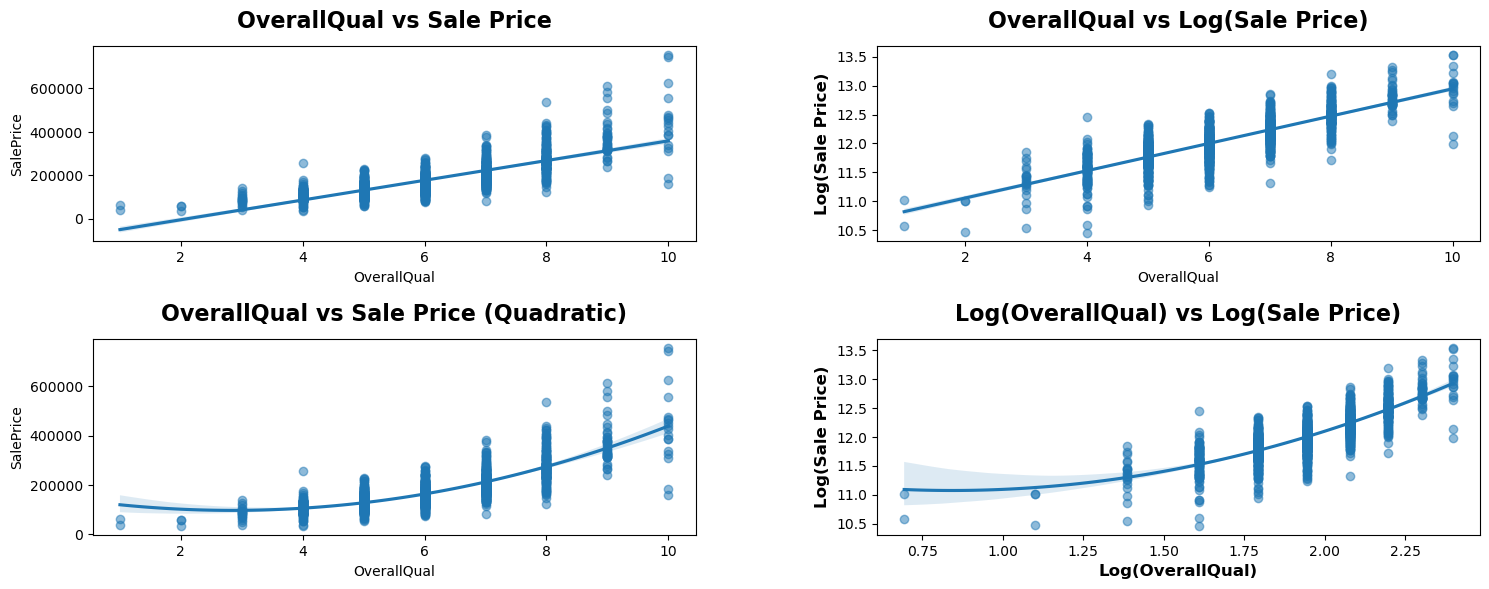

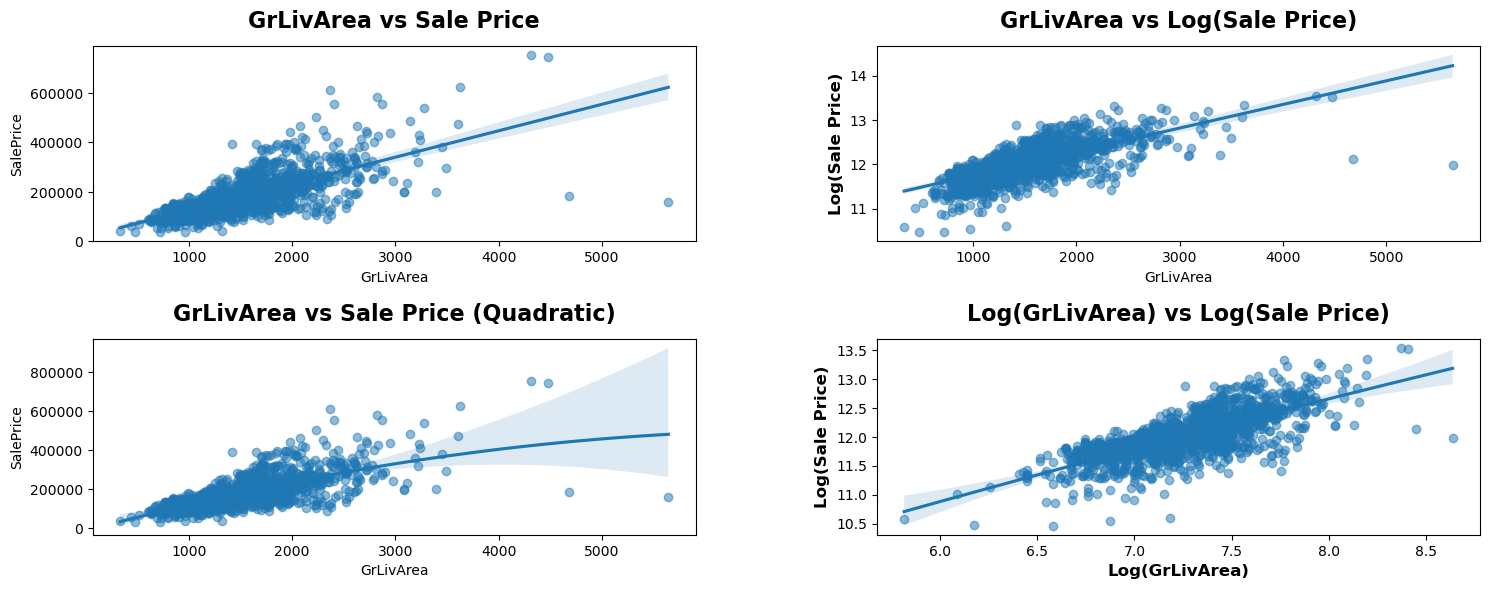

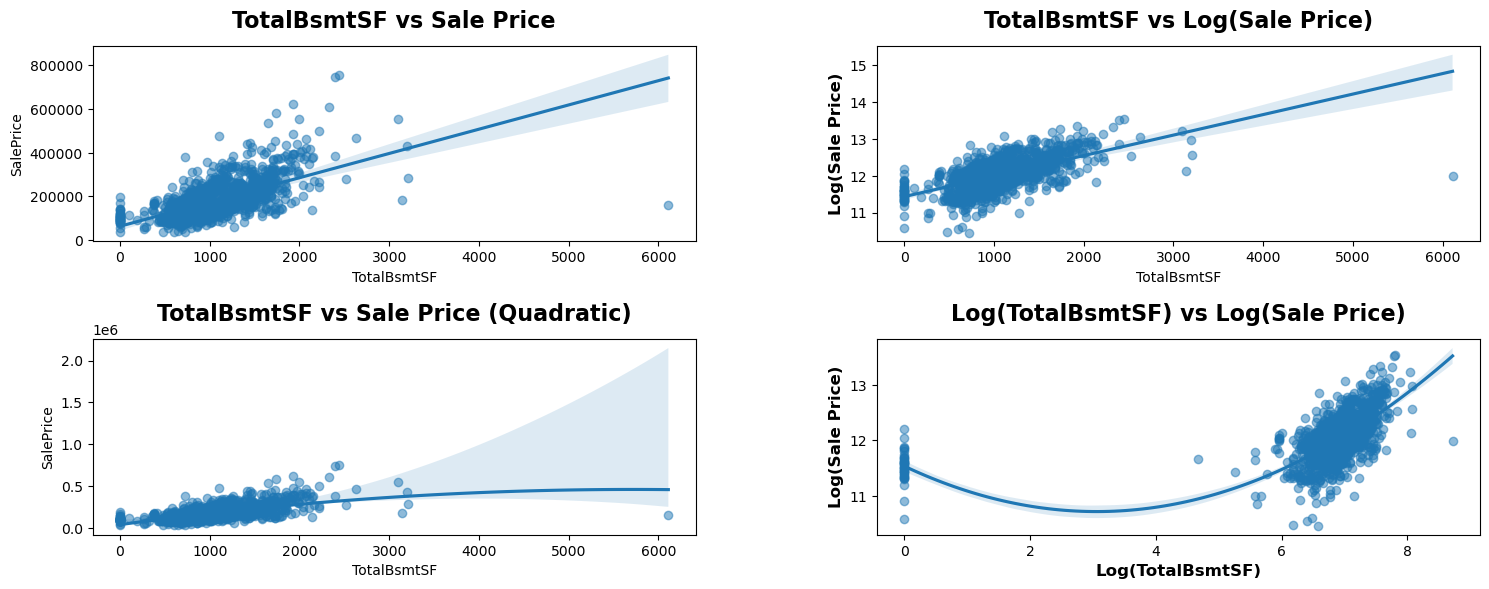

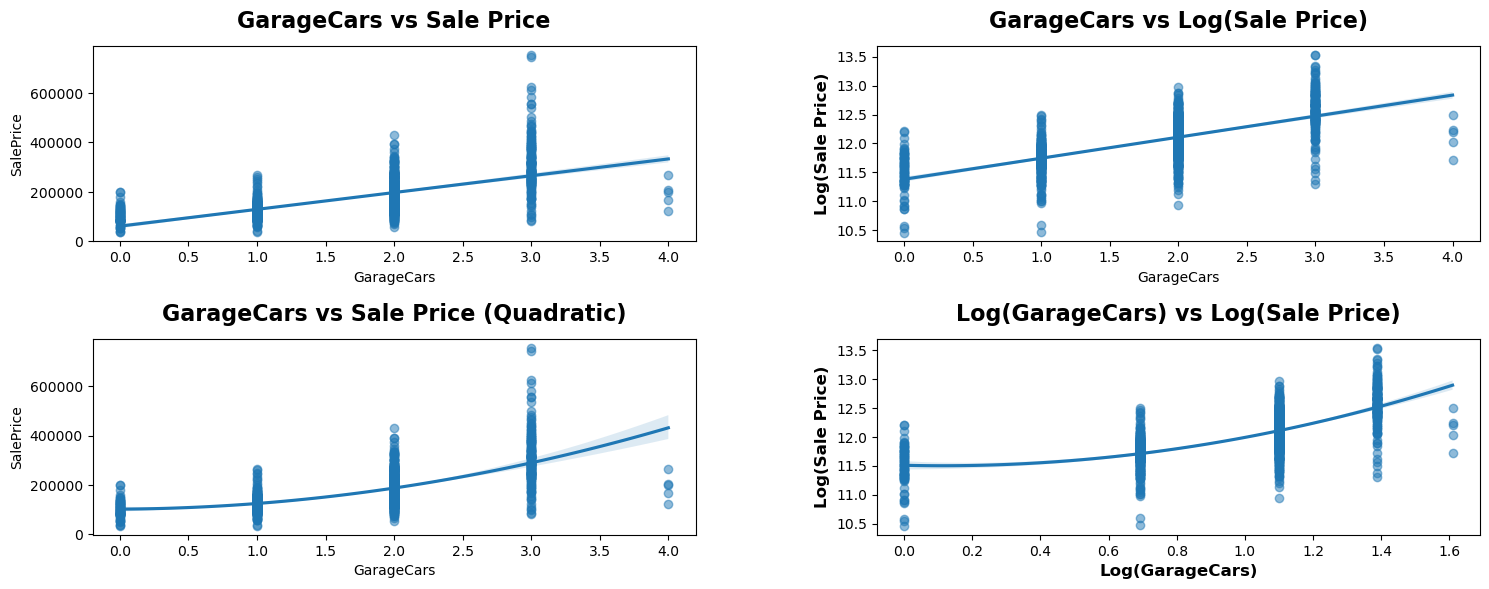

In [143]:

def plot_scatter(feature):
    fig, ax = plt.subplots(2, 2, figsize=(15, 6))
    
    # Linear relationship
    sns.regplot(x=feature, y='SalePrice', data=df_train, scatter_kws={'alpha':0.5}, ax=ax[0,0])
    ax[0,0].set_title(f'{feature} vs Sale Price', fontdict={'fontsize': 16, 'fontweight': 'bold'}, y=1.05)
    
    # Log transformation of target
    sns.regplot(x=feature, y=np.log1p(df_train['SalePrice']), data=df_train, scatter_kws={'alpha':0.5}, ax=ax[0,1])
    ax[0,1].set_title(f'{feature} vs Log(Sale Price)', fontdict={'fontsize': 16, 'fontweight': 'bold'}, y=1.05)
    ax[0, 1].set_ylabel('Log(Sale Price)', fontsize=12, fontweight='bold')
    
    # Non-linear fit (lowess smoothing)
    sns.regplot(x=feature, y='SalePrice', data=df_train, scatter_kws={'alpha':0.5}, order=2, ax=ax[1,0])
    ax[1,0].set_title(f'{feature} vs Sale Price (Quadratic)', fontdict={'fontsize': 16, 'fontweight': 'bold'}, y=1.05)
    
    # Log transformation of feature and target
    sns.regplot(x=np.log1p(df_train[feature]), y=np.log1p(df_train['SalePrice']), data=df_train, scatter_kws={'alpha':0.5}, order=2, ax=ax[1,1])
    ax[1,1].set_title(f'Log({feature}) vs Log(Sale Price)', fontdict={'fontsize': 16, 'fontweight': 'bold'}, y=1.05)
    ax[1, 1].set_xlabel(f'Log({feature})', fontsize=12, fontweight='bold')
    ax[1, 1].set_ylabel('Log(Sale Price)', fontsize=12, fontweight='bold')
    
    
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3, hspace=0.5)
    plt.show()

# Plot key numeric features
important_numerics = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars']
for feature in important_numerics:
    plot_scatter(feature)

**Key Findings :**

- OverallQual is strongly linearly related to SalePrice, but with a slight non-linear boost at the highest ratings.
- GrLivArea has a strong positive linear relationship with SalePrice, but there are some outliers with very large living area that do not follow the trend.
- Total Basement Square Feet needs log transformation for more linear relationship.
- GarageCars has a positive relationship with SalePrice, but the relationship is not strictly linear, especially for houses with 3 or more garage spaces.


#### **2.4. Correlations**

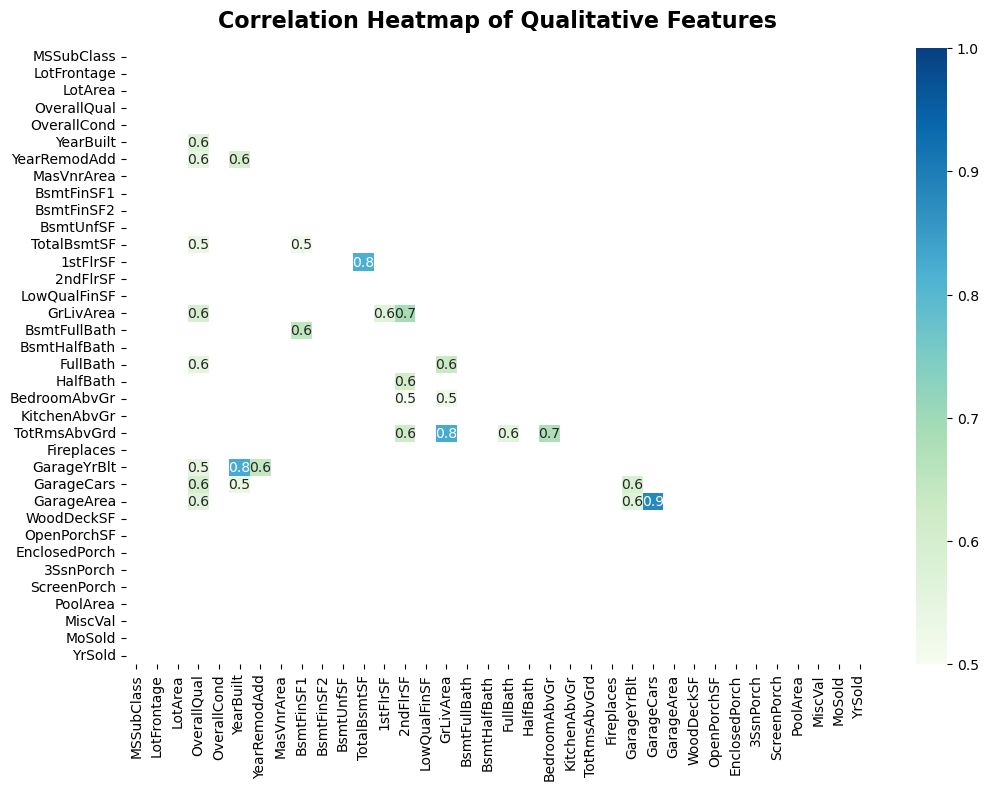

In [144]:
# Create correlation matrix from train data excluding `SalePrice`
corr_mat = df_train.iloc[:, :-1].select_dtypes(include=[np.number]).corr()

# Select correlations greater than 0.5
high_corr_mat = corr_mat[abs(corr_mat) >= 0.5]

# Plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(high_corr_mat,mask = np.triu(np.ones_like(high_corr_mat, dtype=bool)),
            annot=True,
            fmt='.1f',
            cmap='GnBu',
            vmin=0.5,
            vmax=1)
plt.title('Correlation Heatmap of Qualitative Features', fontsize=16, fontweight='bold', y=1.02)

plt.grid(False)
plt.show()



Our training data shows evidence of multicollinearity, with several features exhibiting strong correlations with one another.
- GarageYrBlt and YearBuilt
- 1stFlrSF and TotalBsmtSF
- GarageCars and GarageArea
- GrLivArea and TotRmsAbvGrd

Multicollinearity negatively affects prediction models by increasing the standard errors of estimates. To address this, for each pair of highly correlated features,  will remove the one that shows a weaker correlation with `SalePrice`.

#### **2.5. Missing Values**

Most machine learning algorithms cannot be trained directly on datasets containing missing values. That’s why it’s crucial to detect them first and then decide whether to drop the affected features or impute the missing entries.

        Features  missing  total  percent columns_dtype
0         PoolQC     2909   2919    99.66        object
1    MiscFeature     2814   2919    96.40        object
2          Alley     2721   2919    93.22        object
3          Fence     2348   2919    80.44        object
4     MasVnrType     1766   2919    60.50        object
5    FireplaceQu     1420   2919    48.65        object
6    LotFrontage      486   2919    16.65       float64
7    GarageYrBlt      159   2919     5.45       float64
8   GarageFinish      159   2919     5.45        object
9     GarageQual      159   2919     5.45        object
10    GarageCond      159   2919     5.45        object
11    GarageType      157   2919     5.38        object
12  BsmtExposure       82   2919     2.81        object
13      BsmtCond       82   2919     2.81        object
14      BsmtQual       81   2919     2.77        object


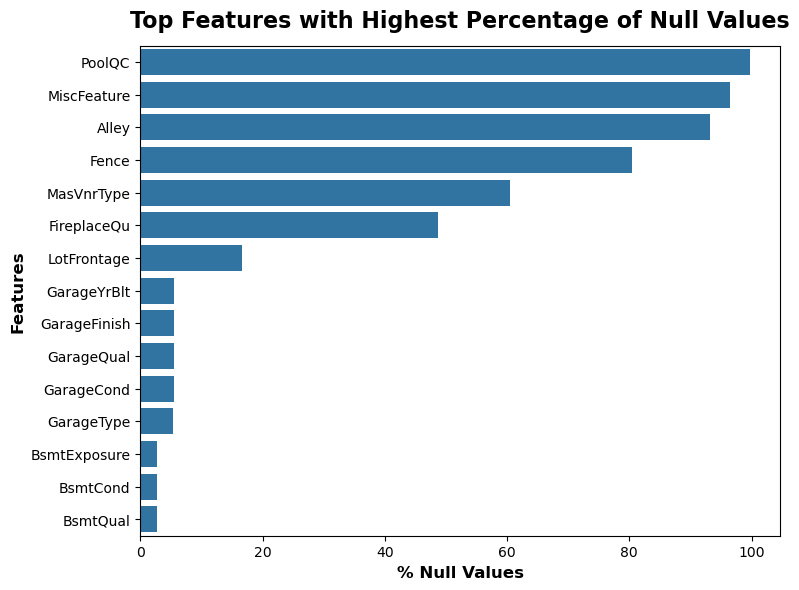

In [145]:
def plot_null_counts(df: pd.DataFrame, top_n: int = 15) -> pd.DataFrame: 
    null_info = df.stb.missing().reset_index().rename({'index':'Features'},axis='columns').sort_values(by='percent',ascending=False)
    null_info['columns_dtype'] = [df[col].dtype for col in null_info['Features']]

    null_info = null_info.loc[null_info['missing']>0].head(top_n)
    print(null_info)

    plt.figure(figsize=(8,6))
    sns.barplot(x='percent', y='Features',data=null_info)
    plt.title('Top Features with Highest Percentage of Null Values', fontsize=16, fontweight='bold', y=1.02)
    plt.xlabel('% Null Values', fontsize=12, fontweight='bold')
    plt.ylabel('Features', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    return 

plot_null_counts(X)


In [146]:
# Checking if missing values affect sale price
def missing_value_impact(feature):
    if df_train[feature].isnull().sum() > 0:
        # Get values for homes with and without the features
        has_feature_prices = df_train[~df_train[feature].isnull()]['SalePrice']
        missing_feature_prices = df_train[df_train[feature].isnull()]['SalePrice']

        # Calculate means
        has_feature_mean = has_feature_prices.mean()
        missing_feature_mean = missing_feature_prices.mean()
        
        print(f'{feature}')
        print(f'  Average price with feature: ${has_feature_mean:.2f}')
        print(f'  Average price without feature: ${missing_feature_mean:.2f}')
        print(f'  Difference: ${has_feature_mean - missing_feature_mean:.2f}')
        print(f"  Count with feature: {len(has_feature_prices)}")
        print(f"  Count without feature: {len(missing_feature_prices)}")
        
        # Only run T-test if we have enough data in both groups
        if len(has_feature_prices) > 1 and len(missing_feature_prices) > 1:
            # Run the T-test
            t_stat, p_value = stats.ttest_ind(
                has_feature_prices,
                missing_feature_prices,
                equal_var=False  # Welch's t-test doesn't assume equal variance
            )
            print(f"  T-test: t-statistic = {t_stat:.2f}, p-value = {p_value:.6f}")
        else:
            print("  T-test: Not enough data in both groups for statistical comparison")


# Check for a few features with missing values
for feature in ['LotFrontage', 'BsmtQual', 'Electrical']:
    if df_train[feature].isnull().sum() > 0:
        missing_value_impact(feature)
        print("\n")


LotFrontage
  Average price with feature: $180770.48
  Average price without feature: $181620.07
  Difference: $-849.59
  Count with feature: 1201
  Count without feature: 259
  T-test: t-statistic = -0.20, p-value = 0.844353


BsmtQual
  Average price with feature: $182878.28
  Average price without feature: $105652.89
  Difference: $77225.39
  Count with feature: 1423
  Count without feature: 37
  T-test: t-statistic = 14.70, p-value = 0.000000


Electrical
  Average price with feature: $180930.39
  Average price without feature: $167500.00
  Difference: $13430.39
  Count with feature: 1459
  Count without feature: 1
  T-test: Not enough data in both groups for statistical comparison




#### **2.6. Outlier Analysis**

Lets look at percentage of possible outliers in numerical features.

In [147]:
"""
Calculate the percentage of outliers based on winsorization method for all the numerical features in the DataFrame.

Parameters:
df(pd.DataFrame): The input DataFrame containing numerical features.
lower_percentile(float): The lower percentile foe winsorization. Default is 5.
upper_percentile(float): The upper percentile for winsorization. Default is 95.

Returns:
pd.DataFrame : A DataFrame containing the columns name and percentage of outliers for each numerical features.
"""

#numeric_df = df_train[df_train.columns.difference(['SalePrice'])]
numeric_df = X.select_dtypes(include='number')
outliers_percentages = {}
for col in numeric_df.columns:
    x_low, x_high = np.percentile(numeric_df[col].dropna(),[1,99])
    total_values = len(numeric_df[col])
    outliers = len(numeric_df[~numeric_df[col].between(x_low,x_high)])
    outliers_percentage = round((outliers / total_values)*100 , 2)
    outliers_percentages[col] = outliers_percentage
    
outliers_df = pd.DataFrame(list(outliers_percentages.items()), columns=['Features','Outliers Percentage'])
outliers_data = outliers_df.sort_values(by='Outliers Percentage', ascending=False).reset_index(drop=True)
outliers_data.head(10)



,Features,Outliers Percentage
0,LotFrontage,17.51
1,GarageYrBlt,6.41
2,GrLivArea,2.06
3,1stFlrSF,2.02
4,YearBuilt,1.85
5,MasVnrArea,1.78
6,LotArea,1.68
7,TotRmsAbvGrd,1.54
8,BsmtFinSF1,1.06
9,BsmtFinSF2,1.06


With some basic understandings of the data set and features, let's do data preprocessing and statistical test.




## **3. Data Preprocessing and Feature Engineering**

#### **3.1 Missing Values Treatment**

In [148]:
miss_df = datatype_df(X)
miss_df['total'] = X.shape[0]
miss_df['missing_percentage'] = 100 * miss_df['missing_value'] / X.shape[0]
miss_df = miss_df.sort_values(by='missing_percentage', ascending=False).query("missing_percentage > 0")
print(f"There are {len(miss_df.index)} features with missing data.\n")
display(miss_df[:10])


There are 34 features with missing data.



,Dtype,nunique,unique,missing_value,total,missing_percentage
PoolQC,object,3,"[nan, Ex, Fa, Gd]",2909,2919,99.66
MiscFeature,object,4,"[nan, Shed, Gar2, Othr, TenC]",2814,2919,96.40
Alley,object,2,"[nan, Grvl, Pave]",2721,2919,93.22
Fence,object,4,"[nan, MnPrv, GdWo, GdPrv, MnWw]",2348,2919,80.44
MasVnrType,object,3,"[BrkFace, nan, Stone, BrkCmn]",1766,2919,60.50
FireplaceQu,object,5,"[nan, TA, Gd, Fa, Ex, Po]",1420,2919,48.65
LotFrontage,float64,128,"[65.0, 80.0, 68.0, 60.0, 84.0, 85.0, 75.0, nan...",486,2919,16.65
GarageYrBlt,float64,103,"[2003.0, 1976.0, 2001.0, 1998.0, 2000.0, 1993....",159,2919,5.45
GarageFinish,object,3,"[RFn, Unf, Fin, nan]",159,2919,5.45
GarageQual,object,5,"[TA, Fa, Gd, nan, Ex, Po]",159,2919,5.45


| Group | Variable Type | Features | Count | Imputation Strategy |
|---|---|---|---:|---|
| **Group 1** | Categorical variables where NA means **no feature** | PoolQC, MiscFeature, Alley, Fence, FireplaceQu, GarageType, GarageFinish, GarageQual, GarageCond, BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2, MasVnrType | 15 | Impute missing values with **`None`** |
| **Group 2** | Numerical variables where NA means **no feature** | GarageArea, GarageCars, BsmtFinSF1, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF, BsmtFullBath, BsmtHalfBath, MasVnrArea, GarageYrBlt | 10 | Impute missing values with **`0`** |
| **Group 3** | Other variables | Functional, MSZoning, Electrical, KitchenQual, Exterior1st, Exterior2nd, SaleType, Utilities, LotFrontage, GarageYrBlt | 10 | Categorical → **Mode**<br>LotFrontage → **Median by Neighborhood**<br>GarageYrBlt → **YearBuilt** |


In [149]:
from sklearn.impute import SimpleImputer
X_new = X.copy()
# Group 1:
group_1 = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType',
    'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType'
]
X_new[group_1] = X_new[group_1].fillna("None")

# Group 2:
group_2 = [
    'GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
    'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]

X_new[group_2] = X_new[group_2].fillna(0)

# Group 3:
group_3a = [
    'Functional', 'MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st',
    'Exterior2nd', 'SaleType', 'Utilities'
]

imputer = SimpleImputer(strategy='most_frequent')
X_new[group_3a] = pd.DataFrame(imputer.fit_transform(X_new[group_3a]), index=X.index)

X_new['LotFrontage'] = X_new.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
X_new.loc[X_new['GarageYrBlt'].isnull(), 'GarageYrBlt'] = X_new.loc[X_new['GarageYrBlt'].isnull(), 'YearBuilt']


In [150]:
# Check whether there is any missing data left:
X_new.isnull().sum().sum()

0

All missing values have been handled.




### **3.2.Statistical Test**

#### **3.2.1. T-Test**

In [151]:
from scipy.stats import ttest_ind


# Select categorical features
train = pd.concat([X_new, y], axis='columns').copy()
train = train[~train.isnull().any(axis=1)]
features = ['Street', 'Alley', 'Utilities', 'CentralAir']
results = []

for col in features:
    # Fill NaN with mode
    mode_value = train[col].mode()[0]
    train[col] = train[col].fillna(mode_value)
    
    # Get categories
    categories = train[col].unique()
    
    if len(categories) == 2:  # valid for binary categorical
        group1 = train.loc[train[col] == categories[0], "SalePrice"]
        group2 = train.loc[train[col] == categories[1], "SalePrice"]
        
        # Only run if both groups have at least 2 samples
        if len(group1) > 1 and len(group2) > 1:
            t_stat, p_val = ttest_ind(group1, group2, equal_var=False)
            results.append({"Feature": col, "t_stat": t_stat, "p_value": p_val})
        else:
            results.append({"Feature": col, "t_stat": "N/A", "p_value": "N/A"})
    else:
        results.append({"Feature": col, "t_stat": "N/A", "p_value": "N/A"})

# Display results
ttest_df = pd.DataFrame(results)
print(ttest_df)


      Feature t_stat p_value
0      Street   1.90    0.12
1       Alley    N/A     N/A
2   Utilities    N/A     N/A
3  CentralAir  17.27    0.00


In [152]:
from scipy.stats import ttest_ind

# Select categorical features
train = pd.concat([X_new, y], axis='columns').copy()
train = train[~train.isnull().any(axis=1)]

features = ['Street', 'Alley', 'Utilities', 'CentralAir']
results = []

for col in features:

    # Fill NaN with mode
    mode_value = train[col].mode()[0]
    train[col] = train[col].fillna(mode_value)

    # Get categories
    categories = train[col].unique()

    if len(categories) == 2:

        group1 = train.loc[train[col] == categories[0], "SalePrice"]
        group2 = train.loc[train[col] == categories[1], "SalePrice"]

        if len(group1) > 1 and len(group2) > 1:

            # Welch's independent t-test
            t_stat, p_val = ttest_ind(
                group1,
                group2,
                equal_var=False
            )

            # Welch-Satterthwaite degrees of freedom
            n1 = len(group1)
            n2 = len(group2)

            s1 = group1.var(ddof=1)
            s2 = group2.var(ddof=1)

            df = ((s1/n1 + s2/n2) ** 2) / (
                ((s1/n1) ** 2 / (n1 - 1)) +
                ((s2/n2) ** 2 / (n2 - 1))
            )

            # Eta squared
            eta_squared = t_stat**2 / (t_stat**2 + df)

            # Determine effectiveness
            if eta_squared >= 0.14:
                effectiveness = "Highly Effective"
            elif eta_squared >= 0.06:
                effectiveness = "Moderately Effective"
            elif eta_squared >= 0.01:
                effectiveness = "Weakly Effective"
            else:
                effectiveness = "Very Weak"

            results.append({
                "Feature": col,
                "Group 1": categories[0],
                "Group 1 Size": len(group1),
                "Group 2": categories[1],
                "Group 2 Size": len(group2),
                "t_stat": round(t_stat, 4),
                "df": round(df, 4),
                "p_value": round(p_val, 6),
                "eta_squared": round(eta_squared, 4),
                "Effectiveness": effectiveness
            })

        else:
            results.append({
                "Feature": col,
                "Group 1": categories[0] if len(categories) > 0 else None,
                "Group 1 Size": len(group1),
                "Group 2": categories[1] if len(categories) > 1 else None,
                "Group 2 Size": len(group2),
                "t_stat": None,
                "df": None,
                "p_value": None,
                "eta_squared": None,
                "Effectiveness": "N/A"
            })

    else:
        results.append({
            "Feature": col,
            "t_stat": None,
            "df": None,
            "p_value": None,
            "eta_squared": None,
            "Effectiveness": "N/A"
        })

# Create DataFrame
ttest_df = pd.DataFrame(results)

# Sort by eta squared
ttest_df = ttest_df.sort_values(
    by="eta_squared",
    ascending=False
).reset_index(drop=True)

display(ttest_df)


,Feature,Group 1,Group 1 Size,Group 2,Group 2 Size,t_stat,df,p_value,eta_squared,Effectiveness
0,CentralAir,Y,1365.00,N,95.00,17.27,148.84,0.00,0.67,Highly Effective
1,Street,Pave,1454.00,Grvl,6.00,1.90,5.06,0.12,0.42,Highly Effective
2,Alley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N/A
3,Utilities,AllPub,1459.00,NoSeWa,1.00,NaN,NaN,NaN,NaN,N/A


#### **3.2.2. ANOVA TEST**

In [153]:
# Combine X and y
df = pd.concat([X_new, y], axis='columns').copy()

# Remove rows containing missing values
df = df.dropna()

# Select categorical features
cat_columns = df.select_dtypes(include='object').columns
target_data = df['SalePrice']

results = []

for col in cat_columns:

    # Only consider categorical features with more than 2 categories
    if df[col].nunique() > 2:

        # Create groups for each category
        groups = [
            target_data[df[col] == category]
            for category in df[col].unique()
        ]

        # Remove empty groups
        groups = [group for group in groups if len(group) > 0]

        # Check if ANY group has fewer than 2 observations
        if any(len(group) < 2 for group in groups):

            results.append({
                'Feature': col,
                'Group_Count': len(groups),
                'Group_Sizes': [len(group) for group in groups],
                'F_value': None,
                'P_value': None,
                'Eta_squared': None,
                'Effectiveness': None
            })

            continue

        # Perform one-way ANOVA
        f_value, p_value = stats.f_oneway(*groups)

        # Calculate eta squared
        grand_mean = target_data.mean()

        ss_between = sum(
            len(group) * (group.mean() - grand_mean) ** 2
            for group in groups
        )

        ss_total = sum(
            (target_data - grand_mean) ** 2
        )

        eta_squared = ss_between / ss_total

        # Determine effectiveness
        if eta_squared >= 0.14:
            effectiveness = "Highly Effective"
        elif eta_squared >= 0.06:
            effectiveness = "Moderately Effective"
        elif eta_squared >= 0.01:
            effectiveness = "Weakly Effective"
        else:
            effectiveness = "Very Weak"

        results.append({
            'Feature': col,
            'Group_Count': len(groups),
            'Group_Sizes': [len(group) for group in groups],
            'F_value': round(f_value, 2),
            'P_value': round(p_value, 6),
            'Eta_squared': round(eta_squared, 4),
            'Effectiveness': effectiveness
        })

# Create DataFrame
results_df = pd.DataFrame(results)

# Sort by effect size
results_df = results_df.sort_values(
    by='Eta_squared',
    ascending=False,
    na_position='last'
).reset_index(drop=True)

display(results_df.head(10))


,Feature,Group_Count,Group_Sizes,F_value,P_value,Eta_squared,Effectiveness
0,Neighborhood,25,"[150, 11, 51, 41, 49, 86, 73, 113, 58, 74, 77,...",71.78,0.00,0.55,Highly Effective
1,ExterQual,4,"[488, 906, 52, 14]",443.33,0.00,0.48,Highly Effective
2,BsmtQual,5,"[618, 649, 121, 37, 35]",316.15,0.00,0.47,Highly Effective
3,KitchenQual,4,"[586, 735, 100, 39]",407.81,0.00,0.46,Highly Effective
4,GarageFinish,4,"[422, 605, 352, 81]",213.87,0.00,0.31,Highly Effective
5,FireplaceQu,6,"[690, 313, 380, 33, 24, 20]",121.08,0.00,0.29,Highly Effective
6,Foundation,6,"[647, 634, 146, 3, 24, 6]",100.25,0.00,0.26,Highly Effective
7,GarageType,7,"[870, 387, 88, 9, 81, 19, 6]",80.38,0.00,0.25,Highly Effective
8,BsmtFinType1,7,"[418, 220, 430, 133, 148, 37, 74]",64.69,0.00,0.21,Highly Effective
9,MasVnrType,4,"[445, 872, 128, 15]",108.91,0.00,0.18,Highly Effective


In [154]:
# NOTE:
# TTest + ANOVA test: it is logical to exclude a categorical feature if any category has only 1 observation + remove insiginificant features, i.e., p_value > 0.01
ttest_remove_cols = ttest_df.query('p_value > 0.01')['Feature'].values.tolist() + ttest_df.query('t_stat.isna()')['Feature'].values.tolist()

anova_remove_cols = results_df.query('P_value > 0.01')['Feature'].values.tolist() + results_df.query('F_value.isna()')['Feature'].values.tolist()  

total_remove_cols = ttest_remove_cols + anova_remove_cols
display(total_remove_cols)


['Street',
 'Alley',
 'Utilities',
 'LandSlope',
 'Condition2',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'ExterCond',
 'Heating',
 'HeatingQC',
 'Electrical',
 'Functional',
 'MiscFeature']

Some of the features explained

| Rank | Feature | F-statistic | p-value | Interpretation |
|---:|---|---:|---:|---|
| 1 | **`ExterQual`** | 443.33 | ~0 | ♦ Exterior quality has a very strong effect on house prices.<br>♦ Homes with better exterior materials and quality tend to sell for significantly higher prices. |
| 2 | **`KitchenQual`** | 407.81 | ~0 | ♦ Kitchen quality is a major driver of sale price.<br>♦ Higher-quality kitchen finishes and condition are associated with higher sale prices. |
| 3 | **`Foundation`** | 100.25 | ~0 | ♦ Foundation type significantly influences house prices.<br>♦ Certain foundation types are associated with higher-value homes. |
| 4 | **`HeatingQC`** | 88.39 | ~0 | ♦ Heating quality has a significant relationship with sale price.<br>♦ Homes with better heating quality tend to have higher sale prices. |
| 5 | **`Neighborhood`** | 71.78 | ~0 | ♦ Location within Ames strongly affects house prices.<br>♦ Different neighborhoods explain significant variation in sale prices. |


#### **3.3. Outliers Treatment**

Because regression models are very sensitive to outlier, we need to be aware of them. Let's examine outliers with a scatter plot.



In [155]:
outliers_data.head(10)


,Features,Outliers Percentage
0,LotFrontage,17.51
1,GarageYrBlt,6.41
2,GrLivArea,2.06
3,1stFlrSF,2.02
4,YearBuilt,1.85
5,MasVnrArea,1.78
6,LotArea,1.68
7,TotRmsAbvGrd,1.54
8,BsmtFinSF1,1.06
9,BsmtFinSF2,1.06


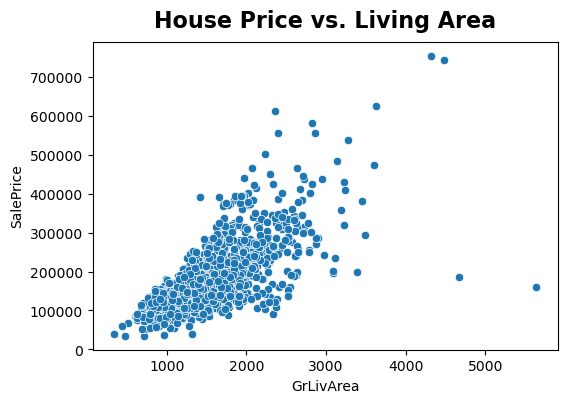

In [156]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df_train, ax=ax)
ax.set_title('House Price vs. Living Area', fontsize=16, fontweight='bold', y=1.02)
plt.show()


There are two observations lying separately from the rest. They have large living area but low price. They are the outliers that we are looking for. Will delete them from the training set.


In [157]:
outlier_index = df_train[(df_train.GrLivArea > 4000)
                           & (df_train.SalePrice < 200000)].index
X_new.drop(outlier_index, axis="index", inplace=True)
y.drop(outlier_index, axis="index", inplace=True)



#### **3.4. Feature Engineering**



##### **3.4.1. Create New Variables**

In this step I will create new features from weaker features in the training data. For example, the surface area of each floor has low correlation with house price; however, when we sum them up, the relationship becomes much stronger. In fact, __TotalSqFeet becomes the strongest feature in the dataset. The new features I will create are total square feet, total number of bathrooms, age of the house, whether the house was remodeled, and whether the house was sold in the same year it was built.__



In [158]:
X_new['totalSqFeet'] = X_new['TotalBsmtSF'] + X_new['1stFlrSF'] + X_new['2ndFlrSF']
X_new['totalBathroom'] = X_new['FullBath'] + X_new['BsmtFullBath'] + 0.5 * (X_new['HalfBath'] + X_new['BsmtHalfBath'])
X_new['houseAge'] = X_new['YrSold'] - X_new['YearBuilt']
X_new['reModeled'] = np.where(X_new['YearRemodAdd'] == X_new['YearBuilt'], 0, 1).astype('bool')
X_new['isNew'] = np.where(X_new['YrSold'] == X_new['YearBuilt'], 1, 0).astype('bool')



In [159]:
X_new.dtypes.value_counts()

object     43
int64      26
float64    13
bool        2
Name: count, dtype: int64

##### **3.4.2. Label Encoding**

Ordinal categorical features are label encoded.



In [160]:
from sklearn.preprocessing import LabelEncoder

# Ordinal categorical columns
for col in ordinal_qual_cond_var:
    qual_map = {'No': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
    X_new[col+"Numeric"] = X_new[col].map(lambda x: qual_map.get(x, 0))  # Map to numeric, default to 0 for 'No' or missing

# for ordinal features based on basement and finish types
X_new['BsmtExposureNumeric'] = X_new['BsmtExposure'].map({'No': 0, 'Mn': 1, 'Av': 3, 'Gd': 4})
X_new['BsmtFinType1Numeric'] = X_new['BsmtFinType1'].map({'No': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6})
X_new['BsmtFinType2Numeric'] = X_new['BsmtFinType2'].map({'No': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6})
X_new['GarageFinishNumeric'] = X_new['GarageFinish'].map({"No":0, "Unf":1, "RFn":2, "Fin":3})

# For ordinal features based on functional and utility
X_new['LotShapeNumeric'] = X_new['LotShape'].map({"IR3" : 1, "IR2" : 2, "IR1" : 3, "Reg" : 4})
X_new['FenceNumeric'] = X_new['Fence'].map({"No":0, "MnWw":1, "GdWo":2, "MnPrv":3, "GdPrv":4})
X_new['FunctionalNumeric'] = X_new['Functional'].map({"Sal":1, "Sev":2, "Maj2":3, "Maj1":4, "Mod":5, "Min2":6, "Min1":7, "Typ":8})
X_new['UtilitiesNumeric'] = X_new['Utilities'].map({"ELO":1, "NoSeWa":2, "NoSewr":3, "AllPub":4})


In [161]:
df = pd.concat([X_new,y], axis="columns").dropna()
df.head()
df.stb.missing().query("missing > 0")

,missing,total,percent


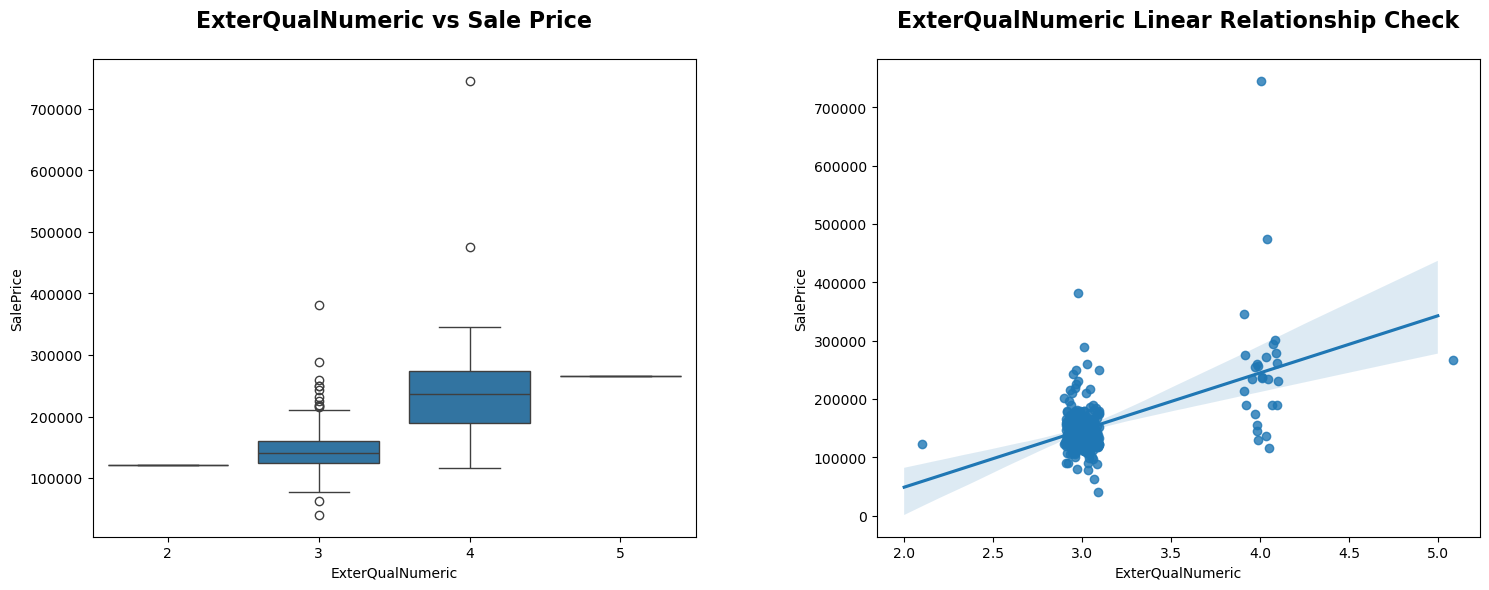

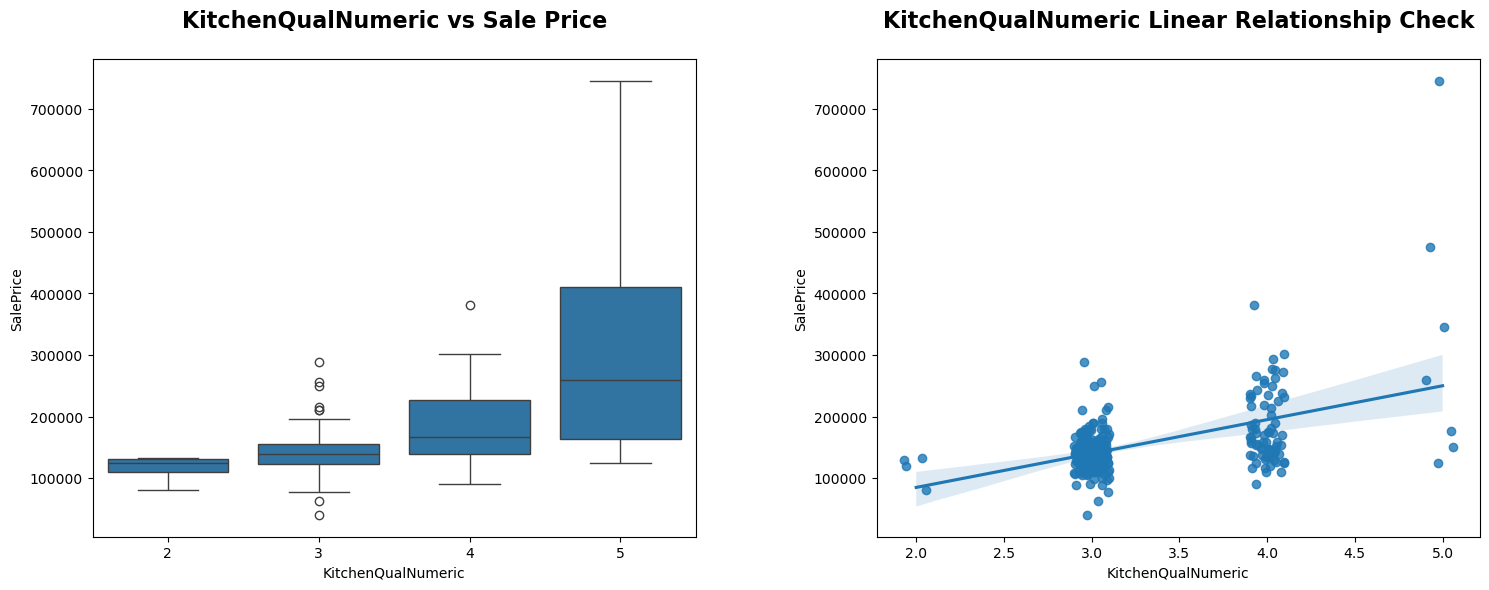

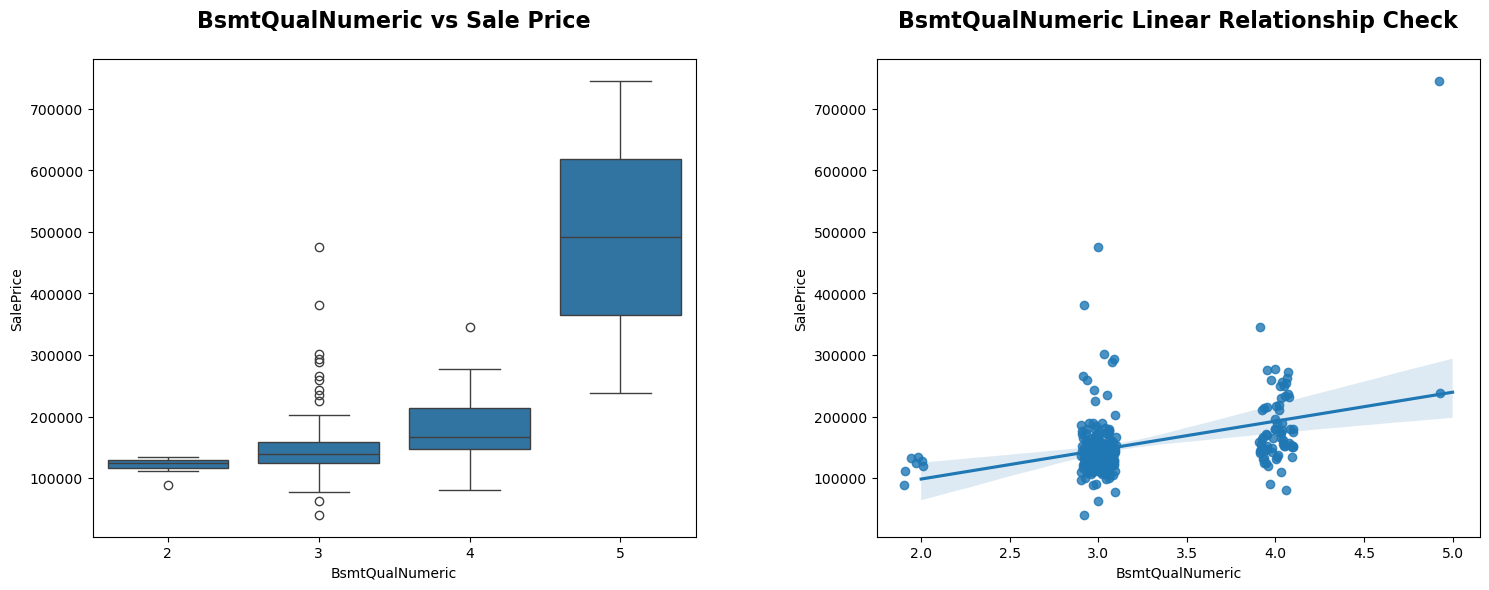

**Key Findings:** - **Ordinal encoding effect:** Transforming these ordinal categories into numbers reveals a clear upward trend — higher quality scores correspond to higher sale prices in a near‑linear fashion.

In [162]:
# Visualizing some distributions of the new features with respect to SalePrice
for feature in ['ExterQualNumeric', 'KitchenQualNumeric', 'BsmtQualNumeric']:
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))

    # Boxplot
    sns.boxplot(x=feature, y='SalePrice', data=df[~df['SalePrice'].isnull()], ax=ax[0])
    ax[0].set_title(f'{feature} vs Sale Price', fontsize=16, fontweight='bold', y=1.05)

    # Regression plot
    sns.regplot(x=feature, y='SalePrice', data=df[~df['SalePrice'].isnull()], x_jitter=0.1, ax=ax[1])
    ax[1].set_title(f'{feature} Linear Relationship Check', fontsize=16, fontweight='bold', y=1.05)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    plt.show()

display_md("**Key Findings:** - **Ordinal encoding effect:** Transforming these ordinal categories into numbers reveals a clear upward trend — higher quality scores correspond to higher sale prices in a near‑linear fashion.")



##### **3.3.3. Transform Numerical Variables to Categorical Variables**

Because I have calculated age of houses, YearBuilt is no longer needed. However, YrSold could have a large impact on house price (e.g. In economic crisis years, house price could be lower). Therefore, I will transform it into categorical variables.

Like YrSold, some numerical variables don't have any ordinal meaning (e.g. MoSold, MSSubClass). I will transform them into categorical variables.


In [163]:
to_factor_cols = ['YrSold', 'MoSold', 'MSSubClass']

for col in to_factor_cols:
    X_new[col] = X_new[col].apply(str)



##### **3.4. Non-Linear Relationship : OverallQual and SalePrice**

Correlations:
Original correlation: 0.7176687671708115
Squared term correlation: 0.765809412989808




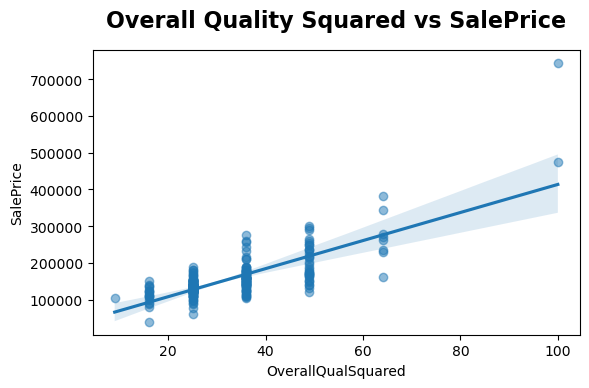

**Key Insights:**

- OverallQual shows stronger effect at the end(suggesting non-linear relationship by squared term)


In [164]:
# Analysis of squared terms for non-linear relationships
df['OverallQualSquared'] = df['OverallQual']**2

print("Correlations:")
print('Original correlation:', df.loc[~df['SalePrice'].isnull(), 'OverallQual'].corr(df.loc[~df['SalePrice'].isnull(), 'SalePrice']))
print('Squared term correlation:', df.loc[~df['SalePrice'].isnull(), 'OverallQualSquared'].corr(df.loc[~df['SalePrice'].isnull(), 'SalePrice']))
print("\n")

plt.figure(figsize=(6,4))
sns.regplot(x='OverallQualSquared', y='SalePrice', data=df[~df['SalePrice'].isnull()], scatter_kws={'alpha':0.5})
plt.title('Overall Quality Squared vs SalePrice', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

display_md("**Key Insights:**")
print("- OverallQual shows stronger effect at the end(suggesting non-linear relationship by squared term)")


##### **3.5. Feature Interaction --- Multiplying Features**

**3.5.1. Quality Size = OverallQual x GrLivArea** 

How does the relationship between house quality (OverallQual) and house size (GrLivArea) jointly influence the sale price in the Ames Housing dataset?

Original Overall Qual correlation: 0.7176687671708115
Original Gr Liv Area correlation: 0.7853487800706104
Original Overall Cond correlation: 0.10916160767527125
Quality × Area interaction correlation: 0.8832340350292279
Quality × Condition interaction correlation: 0.5208211210432756


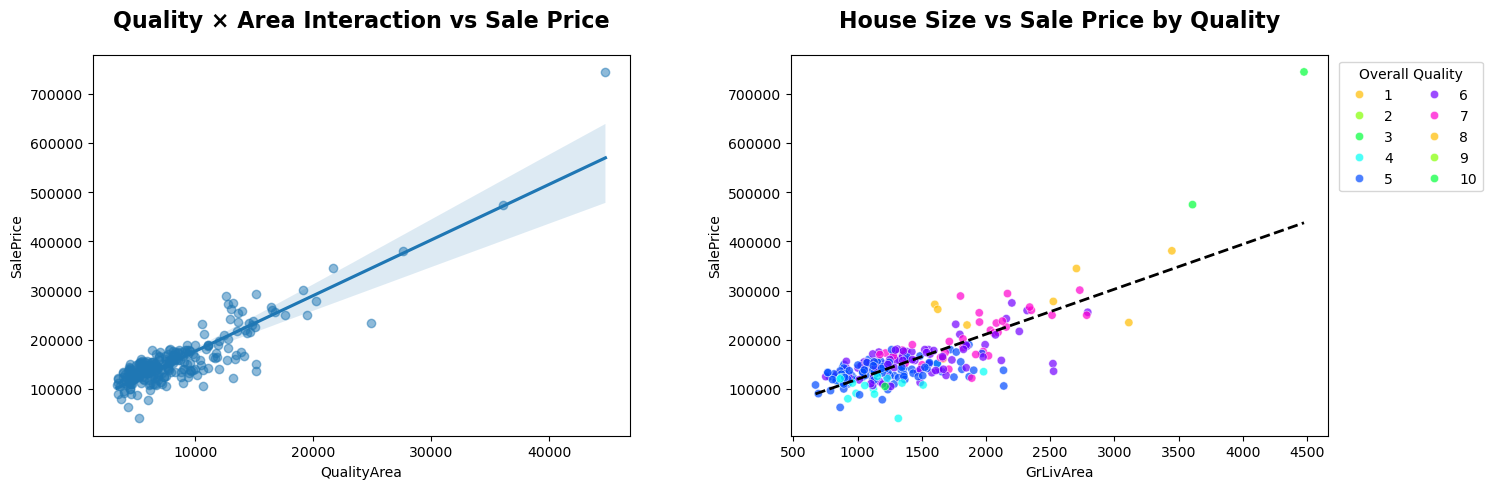

**Insight : Quality × House Size Interaction significant (high-quality, large home size command high premium)**

In [165]:
df_new = df[~df['SalePrice'].isnull()].copy()

df_new.loc[:, 'QualityArea'] = df_new['OverallQual'] * df_new['GrLivArea']
df_new.loc[:, 'QualityCond'] = df_new['OverallQual'] * df_new['OverallCond']

# Checking improvements in correlation
print("Original Overall Qual correlation:", df_new['OverallQual'].corr(df_new['SalePrice']))
print("Original Gr Liv Area correlation:", df_new['GrLivArea'].corr(df_new['SalePrice']))
print("Original Overall Cond correlation:", df_new['OverallCond'].corr(df_new['SalePrice']))
print("Quality × Area interaction correlation:", df_new['QualityArea'].corr(df_new['SalePrice']))
print("Quality × Condition interaction correlation:", df_new['QualityCond'].corr(df_new['SalePrice']))

# Visualize interactions
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Linear relationship
sns.regplot(x='QualityArea', y='SalePrice', data=df_new, scatter_kws={'alpha':0.5}, ax=ax[0])
ax[0].set_title('Quality × Area Interaction vs Sale Price', fontdict={'fontsize': 16, 'fontweight': 'bold'}, y=1.05)

# relationship of house size and house price affected by quality
sns.scatterplot(x='GrLivArea', y='SalePrice', hue='OverallQual', data=df_new, hue_order=range(1, 11), palette=sns.color_palette('hsv', n_colors = len(df_new['OverallQual'].unique())), alpha=0.7, ax=ax[1])
ax[1].set_title('House Size vs Sale Price by Quality', fontdict={'fontsize': 16, 'fontweight': 'bold'}, y=1.05)
ax[1].legend(title='Overall Quality', bbox_to_anchor=(1.3, 1), loc='upper right', ncol=2)

# Linear relationship house size and house price
sns.regplot(x='GrLivArea', y='SalePrice', data=df_new, scatter=False, ci=False, color='k', line_kws={'lw':2, 'ls':'--'}, ax=ax[1])


plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

display_md("**Insight : Quality × House Size Interaction significant (high-quality, large home size command high premium)**")


**3.5.2. Overall Quality vs SalePrice by Neighborhoods**

How does the relationship between overall house quality (OverallQual) and sale price vary across different neighborhoods in Ames?

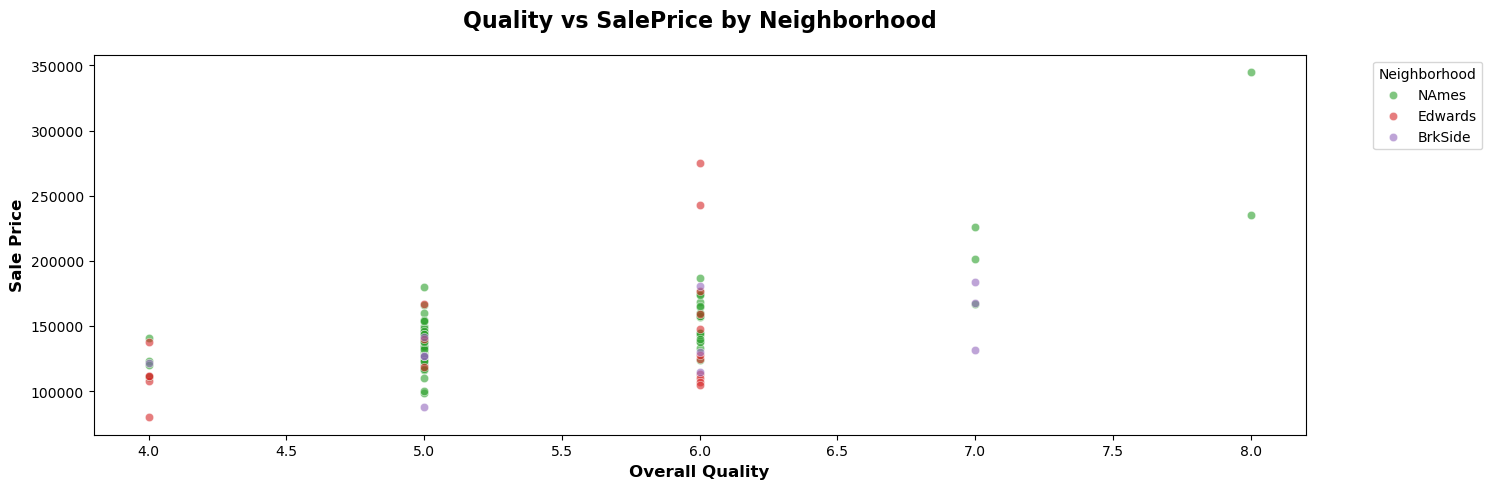

**Insight: Quality x Neighborhood interaction reveals that the value of quality differs across locations and some neighborhoods have higher price premiums for quality than others.**

In [166]:
plt.figure(figsize=(15, 5))
neighborhoods = ['NridgHt', 'StoneBr', 'NAmes', 'Edwards', 'BrkSide']  # select some neighborhoods
for neighborhood in neighborhoods:
    subset = df_new[df_new['Neighborhood'] == neighborhood]
    sns.scatterplot(x='OverallQual', y='SalePrice', data=subset, alpha=0.6, label=neighborhood)

plt.xlabel('Overall Quality', fontsize=12, fontweight='bold')
plt.ylabel('Sale Price', fontsize=12, fontweight='bold')
plt.title('Quality vs SalePrice by Neighborhood', fontsize=16, fontweight='bold', y=1.05)
plt.legend(title='Neighborhood', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

display_md("**Insight: Quality x Neighborhood interaction reveals that the value of quality differs across locations and some neighborhoods have higher price premiums for quality than others.**")



**3.5.3. Age Condition = House Age x Overall Condition**

How does the interaction between age and condition influence buyer perception of value

House Age correlation: -0.23559757724046435
Overall Condition correlation: 0.10916160767527125
Age × Condition interaction correlation: -0.09442425204118711


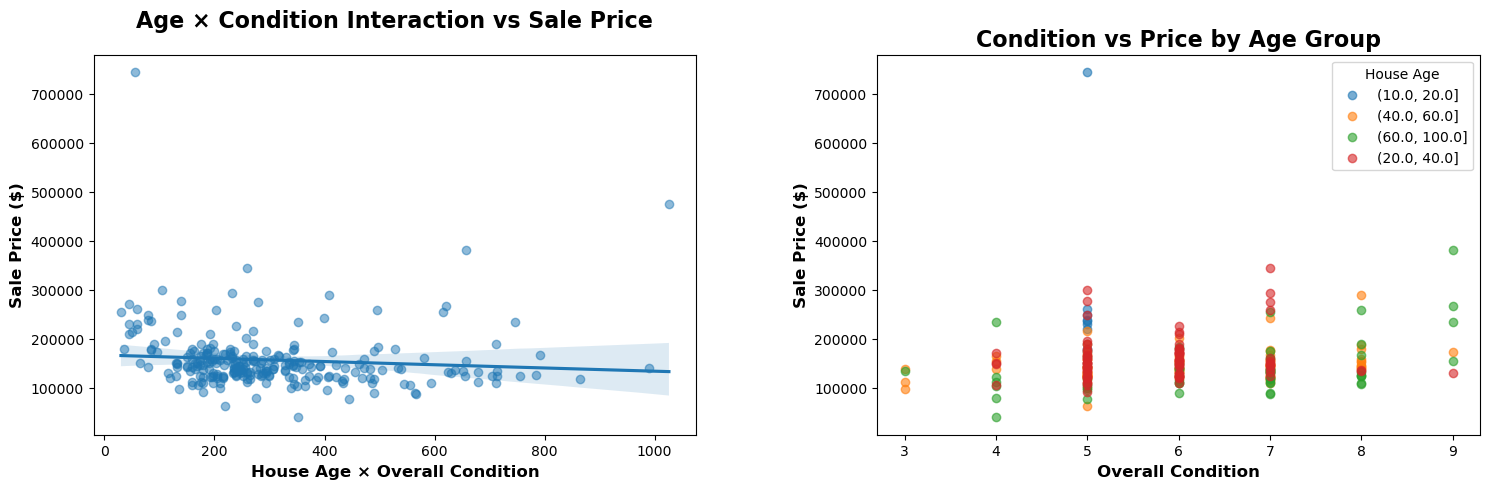

In [167]:
df_new.loc[:, 'HouseAge'] = df_new['YrSold'] - df_new['YearBuilt']
df_new.loc[:, 'AgeCondition'] = df_new['HouseAge'] * df_new['OverallCond']

# Check how this interaction correlates with price compared to individual components
print("House Age correlation:", df_new['HouseAge'].corr(df_new['SalePrice']))
print("Overall Condition correlation:", df_new['OverallCond'].corr(df_new['SalePrice']))
print("Age × Condition interaction correlation:", df_new['AgeCondition'].corr(df_new['SalePrice']))

# Visualize the Age × Condition interaction
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.regplot(x='AgeCondition', y='SalePrice', data=df_new, scatter_kws={'alpha':0.5}, ax=ax[0])
ax[0].set_title('Age × Condition Interaction vs Sale Price', fontdict={'fontsize': 16, 'fontweight': 'bold'}, y=1.05)
ax[0].set_xlabel('House Age × Overall Condition', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Sale Price ($)', fontsize=12, fontweight='bold')


# Check how this interaction works across different age groups
age_bins = [0, 10, 20, 40, 60, 100]
df_new['AgeGroup'] = pd.cut(df_new['HouseAge'], bins=age_bins)

for age_group in df_new['AgeGroup'].unique():
    subset = df_new[df_new['AgeGroup'] == age_group]
    if len(subset) > 10:  # Only plot if enough data points
        ax[1].scatter(subset['OverallCond'], subset['SalePrice'], alpha=0.6, label=str(age_group))
    
ax[1].set_xlabel('Overall Condition', fontsize=12, fontweight='bold')
ax[1].set_ylabel('Sale Price ($)', fontsize=12, fontweight='bold')
ax[1].set_title('Condition vs Price by Age Group', fontsize=16, fontweight='bold')
ax[1].legend(title='House Age', fontsize=10)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

**Insight:**

- The AgeCondition feature (House Age × Overall Condition) captures how maintenance interacts with age, showing that well-kept older homes retain value better while poor condition accelerates depreciation.

- The Age × Condition interaction indicates that newer homes in better condition command higher values.

---

##### __3.6. Skewness and Normalizing Variables__

Normal distribution is one of the assumption that linear regression relies on. Therefore, transfoming skewed data will help our models perform better.

First, let's examine the target variable `SalePrice` with Distribution plot and Quantile-Quantile plot.

__Target variable__



In [168]:
from scipy.stats import norm

def normality_plot(X):
    """
    1. Draw distribution plot with normal distribution fitted curve
    2. Draw Quantile-Quantile plot 
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Histogram with KDE
    sns.histplot(X, kde=True, stat="density", ax=axes[0])
    
    # Fit a normal distribution curve
    mu, sigma = norm.fit(X)
    xmin, xmax = axes[0].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, sigma)
    axes[0].plot(x, p, 'r--', linewidth=2)
    axes[0].set_title(f'Distribution Plot {X.name}', fontsize=16, fontweight='bold', y=1.02)

    # Q-Q plot
    stats.probplot(X, plot=axes[1])
    axes[1].set_title(f'Q-Q Plot {X.name}', fontsize=16, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    plt.show()



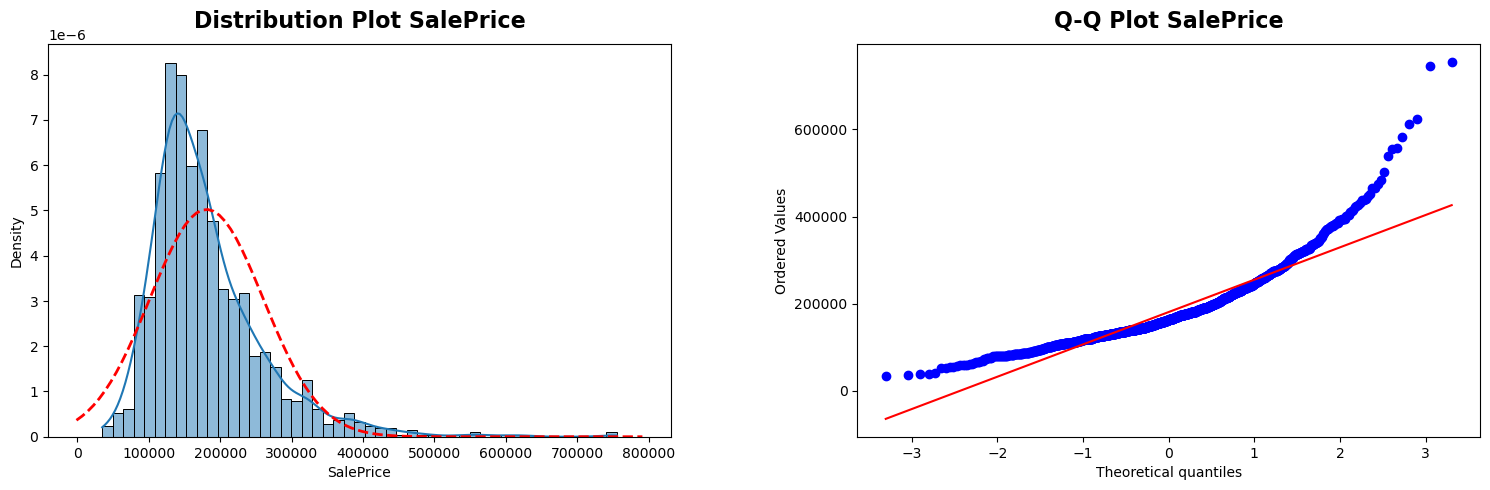

In [169]:
normality_plot(y);



One of the methods to normalize right-skewed data is using log transformation because big values will be pulled to the center. However, log(0) is Nan, so I will use log(1+X) to fix skewness instead.



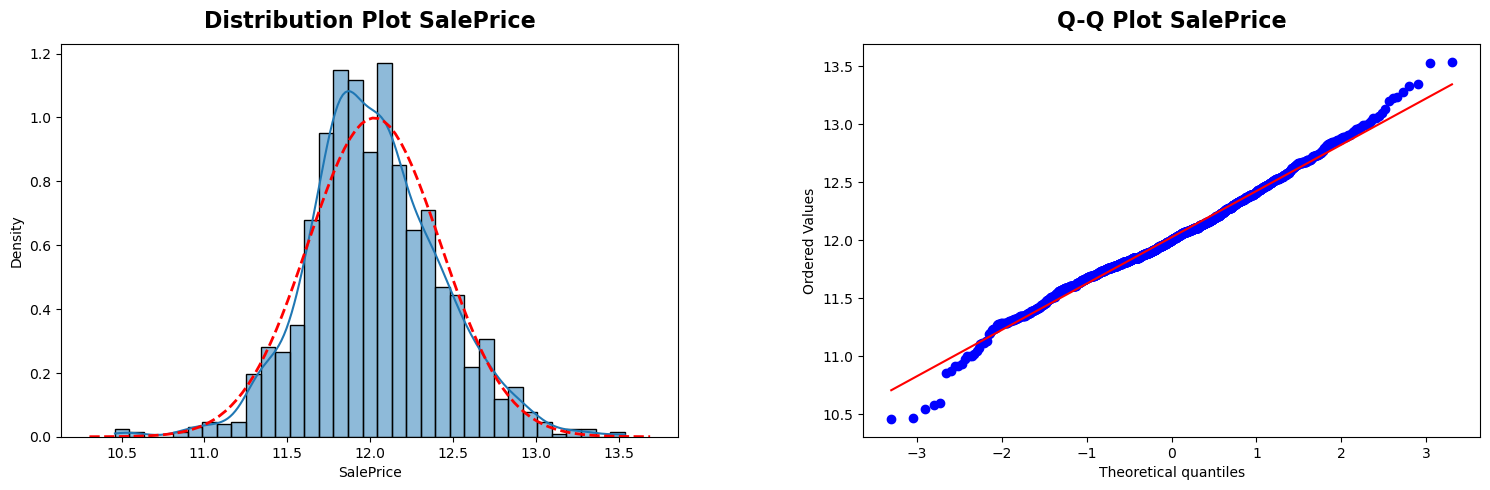

In [170]:
y_new = np.log(1 + y) 
normality_plot(y_new);


And this is `SalePrice` after log transformation. The sknewness has been fixed.


In the next step, I will examine skewness in the rest of numerical features and use transformation to fix them.


__Fixing skewness in other numerical variables__

If skewness is less than -1 or greater than 1, the distribution is __highly skewed__.

If skewness is between -1 and -0.5 or between 0.5 and 1, the distribution is __moderately skewed__.

If skewness is between -0.5 and 0.5, the distribution is __approximately symmetric__.

Below are skewed features in our original train data.



In [171]:
skewness = df_new[num_cols].skew().sort_values(ascending=False)
skewness[abs(skewness) > 0.75]


KitchenAbvGr     9.50
LowQualFinSF     9.20
3SsnPorch        8.92
PoolArea         6.60
MiscVal          5.66
ScreenPorch      4.58
BsmtHalfBath     3.20
OpenPorchSF      3.14
MasVnrArea       3.00
BsmtFinSF2       2.94
EnclosedPorch    2.89
MSSubClass       1.83
GrLivArea        1.81
WoodDeckSF       1.42
LotArea          1.41
1stFlrSF         1.37
TotalBsmtSF      1.30
LotFrontage      1.29
TotRmsAbvGrd     1.18
2ndFlrSF         1.15
FullBath         0.97
OverallQual      0.91
Fireplaces       0.89
HalfBath         0.87
GarageArea       0.83
BsmtUnfSF        0.78
YearBuilt       -0.81
dtype: float64

Let's check normality of GrLivArea:



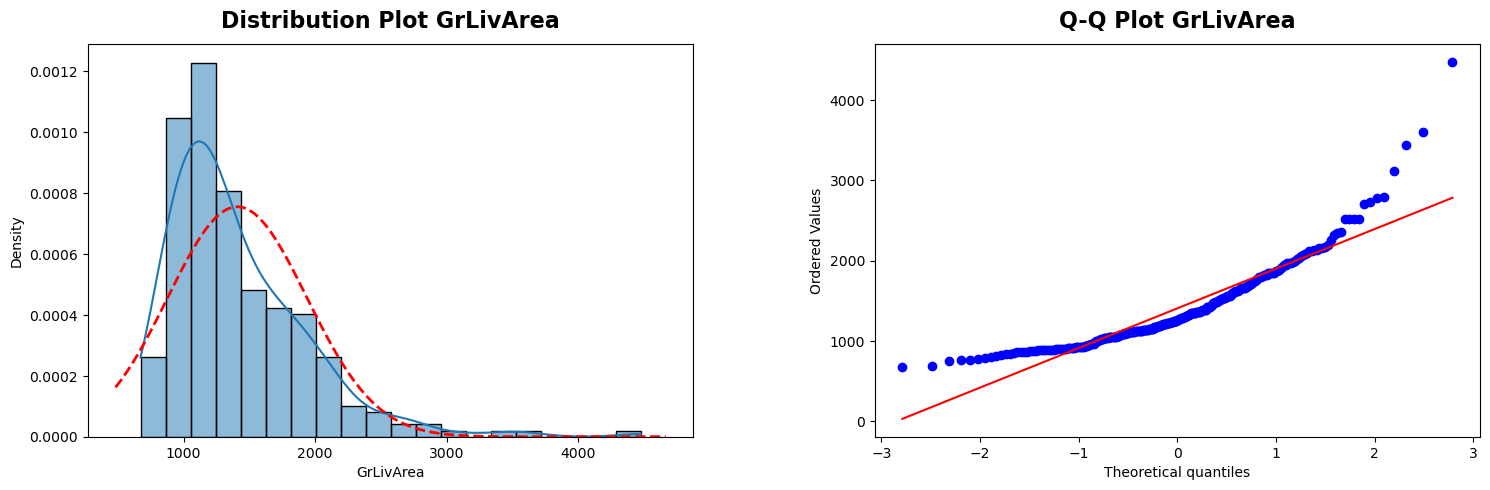

In [172]:
normality_plot(df_new['GrLivArea']);


In [173]:
# List of skewed columns
skewed_cols = list(skewness[abs(skewness) > 0.5].index)

# Remove 'MSSubClass' and 'SalePrice'
skewed_cols = [
    col for col in skewed_cols if col not in ['MSSubClass', 'SalePrice']
]

# Log-transform skewed columns
for col in skewed_cols:
    X_new[col] = np.log(1 + X_new[col])


Below is normality of GrLivArea after log-transformation. Skewness has been fixed.



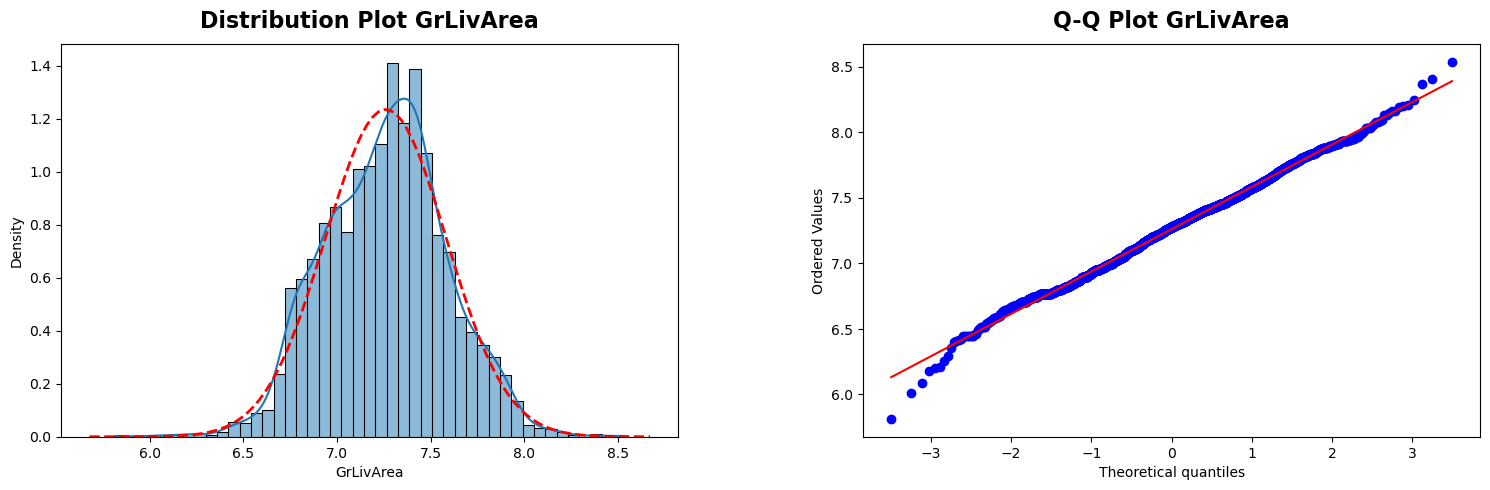

In [174]:
normality_plot(X_new['GrLivArea']);


---
## **4. Data Preprocessing**

In [175]:
def clean_data(df):
    result = df.copy()
    result.columns = result.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")

    # Handle missing values
    """Group 1: Categorical features where missing value likely means absence of the feature, so we fill with 'No'.
    Group 2: Numerical features where missing value likely means zero, so we fill with 0.
    Group 3: Categorical features where we fill missing values with the most frequent category and
    for 'LotFrontage' we fill missing values with the median of the neighborhood, and for 'GarageYrBlt' we fill missing values with 'YearBuilt'."""
    
    group_1 = [
        'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType',
        'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond',
        'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType'
    ]
    result[group_1] = result[group_1].fillna("No")

    group_2 = [
        'GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
        'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
    ]
    result[group_2] = result[group_2].fillna(0)

    group_3a = [
        'Functional', 'MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st',
        'Exterior2nd', 'SaleType', 'Utilities'
    ]
    imputer = SimpleImputer(strategy='most_frequent')
    result[group_3a] = pd.DataFrame(imputer.fit_transform(result[group_3a]), index=result.index)

    result['LotFrontage'] = result.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
    result.loc[result['GarageYrBlt'].isnull(), 'GarageYrBlt'] = result.loc[result['GarageYrBlt'].isnull(), 'YearBuilt']

    return result

# Apply the cleaning function to the dataset
print("="*20, "Data Cleaning", "="*20)
train_cleaned = clean_data(train_org)
test_cleaned = clean_data(test_org)


==================== Data Cleaning ====================


In [176]:
# Checking if cleaning worked
train_missing_after = train_cleaned.isnull().sum().sum()
test_missing_after = test_cleaned.isnull().sum().sum()

print("="*20, "Missing Values After Cleaning", "="*20)
if train_missing_after == 0:
    print("No missing values in training data after cleaning.")
else:
    print(f"Total missing values in training data after cleaning: {train_missing_after}")

if test_missing_after == 0:
    print("No missing values in testing data after cleaning.")
else:
    print(f"Total missing values in testing data after cleaning: {test_missing_after}")



==================== Missing Values After Cleaning ====================
No missing values in training data after cleaning.
No missing values in testing data after cleaning.


In [177]:
# Saving cleaned datasets for next notebook

parent_path = Path.cwd().parent
train_cleaned.to_csv(parent_path.joinpath("data", "processed", "train_cleaned.csv"), index=False)
test_cleaned.to_csv(parent_path.joinpath("data", "processed", "test_cleaned.csv"), index=False)
print("="*20, "Cleaned datasets saved successfully.", "="*20)


==================== Cleaned datasets saved successfully. ====================
